In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw2-task2.ipynb")

# Homework 2 - Task 2: Classification 
## Predicting High Asthma Prevalence : Do Social and Economic Conditions Predict Whether a Community Has Elevated Asthma Risk?

---

### Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, unemployment, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Research consistently shows that communities with greater poverty, unemployment, and minority populations bear a disproportionate share of environmental health burdens — including elevated rates of asthma. But can we actually predict which census tracts are in the top tier of asthma prevalence using only social vulnerability indicators?

**Your goal** is to build and compare two binary classification models — **K-Nearest Neighbors (KNN)** and **Logistic Regression** — that predict whether a census tract falls in the **top third** of asthma prevalence nationally. You will use **5-fold cross-validation** to select the best KNN hyperparameter and compare the results of both models. 

---

### Download the data
Follow these instructions to obtain the data for this assignment: 
1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
1. Select the 2024 dropdown for the United States. 
2. **Choose the CSV File Type, and then click "Go"**. 
3. Add your data to the `task2/` folder. Your fle path should look like this for the autograder to run: `task2/EJI_2024_United_States.csv`. 
3. Don't forget to add your data to your `gitignore`! 


### Dataset 
Each row is a **U.S. census tract**. The variables used in this assignment are:

#### Response Variable

| Column | Description |
|---|---|
| `F_ASTHMA` | **Binary flag** — equals `1` if the tract's asthma prevalence percentile rank (`EPL_ASTHMA`) is above the 66th percentile, `0` otherwise |

#### Predictor Variables

| Column | Description | 
|---|---|
| `EPL_POV200` | Percentile rank for the share of residents below 200% of the federal poverty level | 
| `EPL_UNEMP` | Percentile rank for the civilian unemployment rate |
| `EPL_MINRTY` | Percentile rank for the share of residents identifying as a racial or ethnic minority | 

All three predictors are **percentile ranks** (0 = lowest burden, 1 = highest burden), so they are already on a comparable scale — no standardization is required.

### Setup: Load libraries and read in data

Run the cell below. It loads the EJI data, replaces the EPA missing-value (`-999`) with `NaN`, and takes a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc
)

# Load and clean
df_raw = pd.read_csv('EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


<!-- BEGIN QUESTION -->

---
## Step 1: Explore Class Balance / Imbalance in Response Variable

Before building any model, we need to understand the distribution of our response variable `F_ASTHMA`. This is a binary flag that equals **1** if a census tract's asthma prevalence percentile rank is above the 66th percentile and **0** otherwise.

An imbalanced dataset — where one class appears far more often than the other — can mislead accuracy-based metrics and cause models to favor the majority class. Visualizing class counts first helps us anticipate this.

Create a bar chart of our binary response variable, `F_ASTHMA`. Be sure to include a title, x and y axis labels, and update from the default color. 

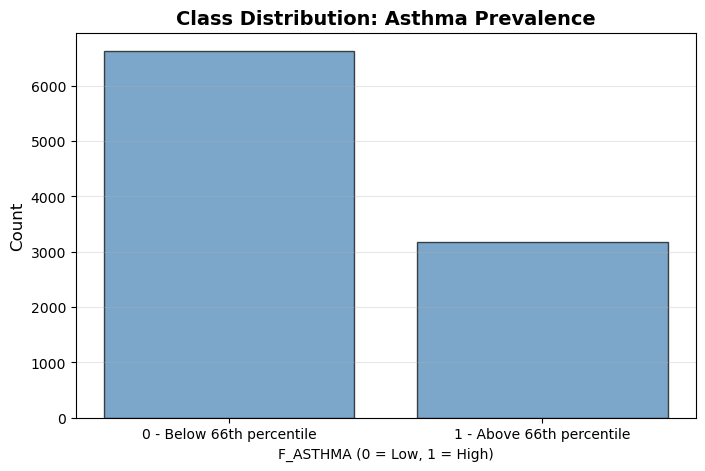

F_ASTHMA
0.0    6634
1.0    3171
Name: count, dtype: int64


In [3]:
# Create a bar chart of the F_ASTHMA distribution
asthma_counts = df['F_ASTHMA'].value_counts().sort_index()

# Plot 
plt.figure(figsize=(8, 5))
plt.bar(asthma_counts.index, asthma_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('F_ASTHMA (0 = Low, 1 = High)', fontsize=10)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution: Asthma Prevalence', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['0 - Below 66th percentile', '1 - Above 66th percentile'])
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print the counts
print(asthma_counts)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

> **Q1:** Describe the class balance / imbalance. If there is an imbalance, how might it affect our classification algorithm? 

There are roughly twice as many class 0 tracts as class 1 tracts. This matters because a model can predict class 0 every time and still hit ~67% accuracy, so overall accuracy becomes a misleading metric. The imbalance also biases the model toward the majority class, meaning it will tend to under-predict high-risk tracts and produce lower recall on the minority class than we'd ideally want.

<!-- END QUESTION -->

---
## Step 2: Prepare Features for Modeling

Complete the following steps:

1. Create a dataframe called `df_model` that contains the following predictor variables: `EPL_POV200`, `EPL_UNEMP`, and `EPL_MINRTY`, and your response variable: `F_ASTHMA`.
2. Drop any rows in `df_model` with NAs. `KNeighborsClassifier` doesn't allow any NAs.
3. Create a variable `X` containing your predictors, and `y` containing your response variable.
4. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.

Because all three predictors are already percentile ranks on a 0–1 scale, features won't dominate KNN distances due to differing units, so no standardization step is needed.

In [4]:
df_model = df[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY', 'F_ASTHMA']].dropna()
X = df_model[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']].values
y = df_model[['F_ASTHMA']].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f'Training set : {X_train.shape[0]:,} tracts')
print(f'Test set     : {X_test.shape[0]:,} tracts')

Training set : 6,813 tracts
Test set     : 2,920 tracts


In [5]:
grader.check("q3")

q3 results: All test cases passed!

---
## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

As a starting point, fit a `KNeighborsClassifier` with `n_neighbors=3` on the training data. Store the fitted model in `knn3`, predictions on the test set in `y_pred_knn3`, and test-set accuracy in `knn3_accuracy`.

**sklearn workflow reminder:**
```python
model = SomeClassifier(...)        # 1. initialize
model.fit(X_train, y_train)        # 2. fit on training data
y_pred = model.predict(X_test)     # 3. predict on test data
acc = accuracy_score(y_test, y_pred)  # 4. evaluate
```
We'll use k = 3 here as a baseline, then use cross-validation in Step 4 to find the optimal k.

In [6]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

y_pred_knn3   = knn3.predict(X_test)
knn3_accuracy = accuracy_score(y_test, y_pred_knn3)

print(f'KNN (K=3) test accuracy: {knn3_accuracy:.4f}')

KNN (K=3) test accuracy: 0.7418


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [7]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 4: Selecting K with 5-Fold Cross-Validation

Choosing K by checking accuracy on a single test split is risky because the result depends on which observations land in the test set. **Cross-validation** gives a more reliable estimate by rotating through multiple train splits on the training data, leaving the test set untouched.

Using `cross_val_score` with `cv=5`, compute the **mean** and **standard deviation** of the 5-fold cross-validation overall accuracy on the **training set** for each K from 1 to 20. Then:

1. Store the mean CV scores in `cv_mean_scores`. (a numpy array of length 20).
2. Plot mean CV accuracy.
3. Store the K with the **highest mean CV score** in `optimal_k` (smallest K in case of a tie) and that score in `best_cv_score`.

Once we have found the best value of K to use, we will run another KNN Model with the test data that hasn't been used to fit any model yet. 

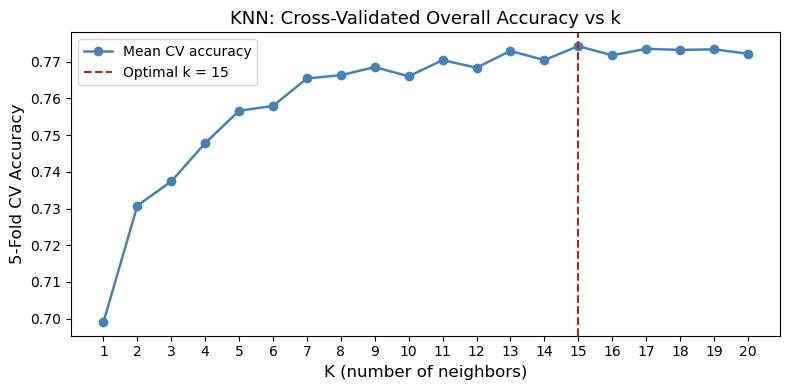

Optimal K = 15,  best mean CV accuracy = 0.7743


In [8]:
k_values       = np.arange(1, 21)
cv_mean_scores = np.array([
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train.ravel(), cv=5, scoring='accuracy').mean()
    for k in k_values
])

optimal_k     = k_values[np.argmax(cv_mean_scores)]
best_cv_score = np.max(cv_mean_scores)

# Visualize optimal k
fig, ax = plt.subplots(figsize=(8, 4))  
ax.plot(k_values, cv_mean_scores, marker='o', color='steelblue', linewidth=1.8, label='Mean CV accuracy')  
ax.axvline(optimal_k, color='firebrick', linestyle='--', label=f'Optimal k = {optimal_k}')  
ax.set_xlabel('K (number of neighbors)', fontsize=12)  
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)  
ax.set_title('KNN: Cross-Validated Overall Accuracy vs k', fontsize=13) 
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  
ax.legend()  
plt.tight_layout()  
plt.show()  

print(f'Optimal K = {optimal_k},  best mean CV accuracy = {best_cv_score:.4f}')

In [9]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2:** Why is using cross-validation to select K better than using the single test-set accuracy from Step 3? What would you e

With a single test split, the accuracy we get depends a lot on how the data was randomly divided. Cross-validation averages across 5 test MSE's per fold, so we're not just optimizing for one particular partition of the data. That gives a more reliable picture of which K actually generalizes well instead of which one happened to work on one split.

<!-- END QUESTION -->

---
## Step 5: KNN with Optimal K
 Re- run your  K-Nearest Neighbors Classifier with number of neighbors equal to  `optimal_k`. Store your accuracy in `knn_optimal_accuracy`.



In [10]:

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

y_pred_knn_optimal = knn_optimal.predict(X_test)
knn_optimal_accuracy = accuracy_score(y_test, y_pred_knn_optimal)

print(f'KNN (K={optimal_k}) test accuracy: {knn_optimal_accuracy:.4f}')


KNN (K=15) test accuracy: 0.7760


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [11]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->


> **Q3:** Compare the test-set accuracy of `knn3` (K = 3) and `knn_optimal` (K = `optimal_k`). Which performed better, and by how much? Why might the optimal K found by cross-validation outperform the arbitrary choice of K = 3?

K=3 got 74.2% accuracy and K=15 got 77.6%, about a 3.3 percentage point improvement. K=3 is noisy with only 3 neighbors since one outlier can flip the prediction. Cross-validation reveals that a larger K smooths out that noise by averaging over more neighbors which turns out to generalize better on the test set.

<!-- END QUESTION -->

---
## Step 6: Logistic Regression with Cross-Validation


We will now create a Logistic Regression with the same predictors and outcome variable. 

1. Create a [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) with `random_state=42` and `cv = 5`. Call it `lr`. The CV at the end of Logistic Regression is for cross fold validation. This allows you to use cross fold validation in your regression. 

>  Unlike plain [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), LogisticRegressionCV automatically selects the best regularization strength C using 5-fold cross-validation. Regularization penalizes large coefficients to reduce overfitting; C controls how strong that penalty is. The cross-validation tries a range of C values and picks the one with the best average held-out accuracy across the 5 folds. 

2. Fit `lr` on the full training set, predict on the test set, and store predictions in `y_pred_lr` and test-set accuracy in `lr_accuracy`. This will be using the default threshold of $\alpha=0.5$.
3. Extract the coefficients from your linear regression with `.coef_[]` and `.intercept_[]`. Create a table with a feature and coefficient column to present your results. 

In [12]:
lr = LogisticRegressionCV(cv=5, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr   = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.7753424657534247

In [13]:
feature_names = ['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY', 'Intercept']
coefficients  = list(lr.coef_[0]) + [lr.intercept_[0]]

pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})



,Feature,Coefficient
0,EPL_POV200,5.008554
1,EPL_UNEMP,0.891915
2,EPL_MINRTY,-1.379598
3,Intercept,-3.320082


In [14]:
grader.check("q9")

q9 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Which predictors have a negative association with a tract being flagged for high asthma prevalence? Interpret one of them in plain 
  language,
>
> **Note:** Notice this is an inference question. In this case we are using only a subset of the training data to answer it for convenience, but the best practice is to use *all the available data* to investigate inference questions and use a *training/test data* splot for prediction.

EPL_MINRTY is the only predictor with a negative coefficient meaning higher minority percentile rank is associated with lower odds of being flagged for high asthma, holding the other predictors constant. This is counterintuitive, but it's likely a result of EPL_POV200 having a dominant coefficient and soaking up most of the shared variance between poverty and minority share. Once poverty is controlled for, minority share flips negative.

<!-- END QUESTION -->

---
## Step 7: Confusion Matrix for Logistic Regression

Compute the **confusion matrix** for the logistic regression predictions on the test set. Store the 2 x 2 numpy array in `cm_lr`. Plot it using `ConfusionMatrixDisplay` with display labels `['0', '1]'`.

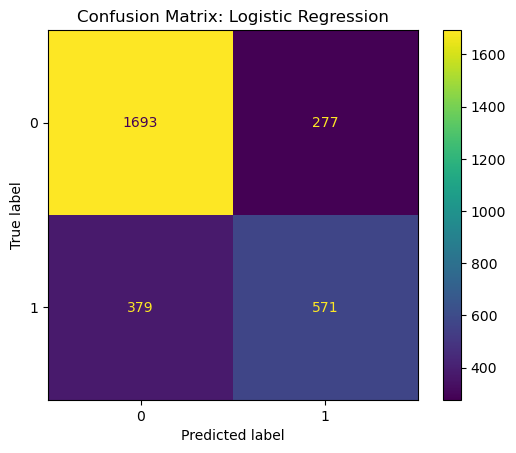

In [15]:
cm_lr = np.array(confusion_matrix(y_test, y_pred_lr))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['0','1'])
disp_lr.plot()
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [16]:
grader.check("q11")

q11 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

- True Negatives (1693): These census tracts had asthma prevalence below the 66th percentile and the model correctly predicted them as low-risk. Their poverty, unemployment, and minority population levels were low enough that the model appropriately said no intervention is needed.

- True Positives (571): Actually had high asthma prevalence (above the 66th percentile) and the model correctly flagged them. The social vulnerability indicators successfully identified these communities as burdened, so they would be appropriately targeted for intervention.

- False Positives (277): Predicted as high-risk but actually had lower asthma prevalence. The model over-estimated the risk based on their social conditions. They'd be flagged for intervention they don't necessarily need thereby wasting public health resources.

- False Negatives (379): Had elevated asthma prevalence but the model predicted them as low-risk. These are communities with asthma burden that would be overlooked and likely miss out on resources or intervention entirely.

<!-- END QUESTION -->

---
## Step 8: Accuracy Metrics for Logistic Regression

 Calculate accuracy, precision, recall, and the F1 score. Store your results in `accuracy_lr`, `precision_lr`, `recall_lr`, and `f1_lr` with the functions from `sklearn.metrics`.

In [1]:
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)

print(f'Accuracy  = {accuracy_lr:.4f}')
print(f'Precision = {precision_lr:.4f}')
print(f'Recall    = {recall_lr:.4f}')
print(f'F1 Score  = {f1_lr:.4f}')

NameError: name 'accuracy_score' is not defined

In [ ]:
grader.check("q13")

q13 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Compare the accuracy, precision, recall, and F1 score for the logistic regression model. In the context of predicting high asthma risk tracts, which metric do you think is most important, and why? What is the trade-off between precision and recall here?

Recall is the most important metric becasue missing a truly high-risk tract is worse than falsely flagging a low-risk one. A false alarm can be checked through follow-up but an overlooked community may never get resources. The model's precision is higher than its recall so it's more conservative about flagging tracts as high risk than it probably should be in this context.

The biggest trade-off is if we lower the decision threshold to increase recall, we'll start flagging more borderline tracts as high risk which means more false positives and lower precision. We'll catching more real cases but also generating more false alarms. Going the other direction of raising the threshold to improve precision means fewer false alarms but more high-risk tracts slip through undetected.

<!-- END QUESTION -->

---
## Step 9: Confusion Matrix and Accuracy Metrics for KNN

Compute and plot the confusion matrix  for the **KNN (K = `optimal_k`)** model. Then calculate precision, recall, and F1 score. This lets you directly compare it to logistic regression beyond just overall accuracy.

In [19]:
cm_knn = np.array(confusion_matrix(y_test, y_pred_knn_optimal))


precision_knn = precision_score(y_test, y_pred_knn_optimal)
recall_knn    = recall_score(y_test, y_pred_knn_optimal)
f1_knn        = f1_score(y_test, y_pred_knn_optimal)

print(f'KNN (k={optimal_k}) Confusion Matrix:\n{cm_knn}\n')
print(f'Precision (KNN): {precision_knn:.4f}')
print(f'Recall    (KNN): {recall_knn:.4f}')
print(f'F1 Score  (KNN): {f1_knn:.4f}')
print()
print('--- Model Comparison ---')
print(f'              KNN (k={optimal_k})    Logistic Reg')
print(f'Accuracy:     {knn_optimal_accuracy:.4f}         {lr_accuracy:.4f}')
print(f'F1 Score:     {f1_knn:.4f}         {f1_lr:.4f}')

KNN (k=15) Confusion Matrix:
[[1717  253]
 [ 401  549]]

Precision (KNN): 0.6845
Recall    (KNN): 0.5779
F1 Score  (KNN): 0.6267

--- Model Comparison ---
              KNN (k=15)    Logistic Reg
Accuracy:     0.7760         0.7753
F1 Score:     0.6267         0.6352


In [20]:
grader.check("q15")

q15 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q7:** Comment on the results of the Logistic Regression vs KNN. How do they compare in terms of performance? Which model would you pick? Why? 

The two models are nearly identical in accuracy, but they trade off differently on precision and recall. KNN has slightly higher precision meaning when it flags a tract as high-risk, it's a bit more likely to be correct. However, Logistic regression (LR) has meaningfully better recall so it catches more of the truly high-risk tracts. LR also edges out KNN on F1 score, reflecting its better overall balance.

I'd pick logistic regression because in a public health context, recall matters more. Missing a high-risk community is a worse outcome than a false alarm. LR catches about 2.3 percentage points more high-risk tracts than KNN. On top of that, the coefficients tell us which factors are actually driving predictions (poverty dominates, unemployment matters less). This is valuable when trying to explain the model to policymakers or justify resource allocation decisions.

<!-- END QUESTION -->

---
## Step 10: ROC Curve and AUC — Logistic Regression

The **Receiver Operating Characteristic (ROC)** curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** across every possible classification threshold — not just the default 0.5 cutoff. This lets us see how the model trades off between catching more high-risk tracts (higher recall) and generating more false alarms (higher FPR).


Follow these steps:

1. **Get predicted probabilities.** Use `lr.predict_proba(X_test)` to get the predicted probability for each test observation. This returns a 2-column array — column 0 is the probability of class 0 (low asthma risk), column 1 is the probability of class 1 (high asthma risk). Keep only the class 1 probabilities and store in `y_proba_lr`.

2. **Compute the ROC curve.** Call `roc_curve(y_test, y_proba_lr)`. It returns three arrays: `fpr` (false positive rates), `tpr` (true positive rates), and `thresholds` — one entry per decision threshold the model evaluated.

3. **Compute AUC.** Pass `fpr` and `tpr` to `auc()` and store the result in `roc_auc`.

4. **Plot the ROC curve.** Create a line plot with `fpr` on the x-axis and `tpr` on the y-axis. Add a dashed diagonal line from (0, 0) to (1, 1) to represent a random classifier. Include axis labels, a title, and a legend that displays the AUC value.

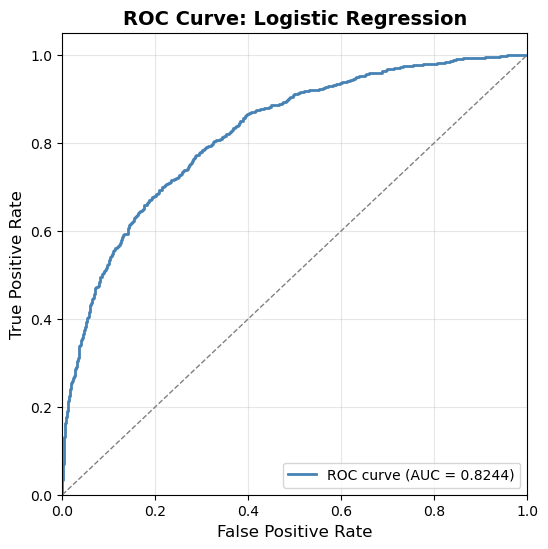

Logistic Regression AUC: 0.8244


In [21]:
y_proba_lr = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Logistic Regression AUC: {roc_auc:.4f}')

In [22]:
grader.check("q17")

q17 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q8:** What does the AUC score tell you about the logistic regression model's ability to distinguish between high and low asthma risk tracts? Is this model meaningfully better than random guessing? How does the shape of the ROC curve reflect the precision-recall trade-off you observed in Step 8?

AUC of 0.82 means the model correctly ranks a high-risk tract above a low-risk one about 82% of the time, which is a meaningful improvement over random guessing (AUC = 0.5 = coin toss).  The ROC curve shape matches what we saw in Step 8. On the left side of the curve (low FPR), the TPR rises quickly. The model can catch a lot of high-risk tracts without generating many false alarms at more selective thresholds. But past a certain point the curve flattens which lines up with the recall of 0.60 at the default threshold getting the remaining high-risk tracts requires accepting a much higher false positive rate.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for autograded questions**

In [23]:
grader.check_all()

q11 results: All test cases passed!

q13 results: All test cases passed!

q15 results: All test cases passed!

q17 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!